In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
PROJECT_DIR = "/content/drive/MyDrive/BreastCancer_Dissertation"
DATA_DIR = f"{PROJECT_DIR}/Data/CBIS-DDSM"

print(PROJECT_DIR)
print(DATA_DIR)

/content/drive/MyDrive/BreastCancer_Dissertation
/content/drive/MyDrive/BreastCancer_Dissertation/Data/CBIS-DDSM


In [7]:
import os

PROJECT_DIR = "/content/drive/MyDrive/BreastCancer_dissertation"
DATA_DIR = os.path.join(PROJECT_DIR, "Data", "CBIS-DDSM")

print("Project Directory:", PROJECT_DIR)
print("Data Directory:", DATA_DIR)

Project Directory: /content/drive/MyDrive/BreastCancer_dissertation
Data Directory: /content/drive/MyDrive/BreastCancer_dissertation/Data/CBIS-DDSM


In [31]:
import os

JPEG_DIR = os.path.join(DATA_DIR, "jpeg")

num_case_folders = len(os.listdir(JPEG_DIR))

print("=" * 50)
print("CBIS-DDSM JPEG Dataset Summary")
print("=" * 50)
print(f"Total DICOM study folders : {num_case_folders}")
print("Each folder contains JPEG images converted from one DICOM study.")

CBIS-DDSM JPEG Dataset Summary
Total DICOM study folders : 6774
Each folder contains JPEG images converted from one DICOM study.


## Load the CBIS-DDSM Mass Training Dataset

The mass training metadata is loaded to inspect the available clinical variables, image paths, ROI mask paths, and pathology labels before performing exploratory data analysis.

In [32]:
import pandas as pd
import os

# Load the CBIS-DDSM mass training metadata
mass_train = pd.read_csv(
    os.path.join(DATA_DIR, "mass_case_description_train_set.csv")
)

print("Dataset columns:")
print(mass_train.columns.tolist())

display(mass_train.head())

Dataset columns:
['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


## Visualisation of ROI Mask and Cropped Lesion

The CBIS-DDSM dataset provides both cropped lesion images and expert-annotated ROI masks. These annotations are used later to evaluate explainability methods and ROI-guided attention supervision.

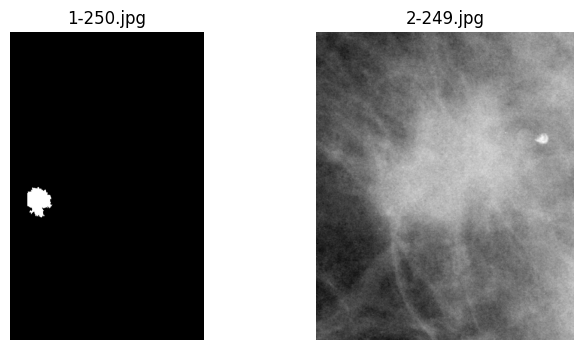

In [16]:
from PIL import Image
import matplotlib.pyplot as plt
import os

roi_folder = os.path.join(DATA_DIR, "jpeg", roi_uid)
files = os.listdir(roi_folder)

plt.figure(figsize=(8,4))

for i, file in enumerate(files):
    img_path = os.path.join(roi_folder, file)
    img = Image.open(img_path)

    plt.subplot(1, len(files), i+1)
    plt.imshow(img, cmap="gray")
    plt.title(file)
    plt.axis("off")

plt.show()

## Dataset Integrity Check

Before performing exploratory data analysis and model development, the image paths stored in the metadata were verified against the downloaded JPEG dataset. This confirms that every mammogram, cropped lesion image and ROI mask referenced in the metadata is available locally.

In [33]:
import os

def uid_from(path):
    return str(path).split("/")[-2]

print("=" * 60)
print("Dataset Integrity Check")
print("=" * 60)

for col in [
    "image file path",
    "cropped image file path",
    "ROI mask file path"
]:
    uids = mass_train[col].apply(uid_from)
    found = uids.apply(
        lambda u: os.path.isdir(os.path.join(JPEG_DIR, u))
    )

    print(f"{col:<25} : {found.sum()}/{len(found)} ({found.mean():.1%})")

Dataset Integrity Check
image file path           : 1318/1318 (100.0%)
cropped image file path   : 1318/1318 (100.0%)
ROI mask file path        : 1318/1318 (100.0%)


## Create an Image-Level Dataset

Multiple abnormalities can exist on the same mammogram. For model training, the metadata is aggregated so that each mammogram corresponds to a single row. If any abnormality on a mammogram is malignant, the image is labelled as malignant.

In [18]:
mass_train["full_jpeg"] = mass_train["image file path"].apply(
    lambda p: next((os.path.join(JPEG_DIR, uid_from(p), f)
                    for f in os.listdir(os.path.join(JPEG_DIR, uid_from(p)))
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))), None)
    if os.path.isdir(os.path.join(JPEG_DIR, uid_from(p))) else None)

mass_train["label"] = (mass_train["pathology"].str.upper() == "MALIGNANT").astype(int)

# one row per physical image; malignant if ANY abnormality on it is malignant
img_df = (mass_train.dropna(subset=["full_jpeg"])
          .groupby(["patient_id", "left or right breast", "image view"], as_index=False)
          .agg(full_jpeg=("full_jpeg", "first"), label=("label", "max")))
print("Linked images:", len(img_df), "| malignant rate:", round(img_df["label"].mean(), 3))

Linked images: 1231 | malignant rate: 0.489


### Observation

After grouping duplicate abnormalities, the dataset contains **1,231 unique mammogram images**. The malignant rate is **48.9%**, indicating that the dataset is approximately balanced at the image level. This balance is suitable for establishing an initial ResNet-50 baseline, although it does not reflect the much lower prevalence of cancer in real-world breast screening populations.

## Class Distribution and Clinical Metadata Analysis

This section explores the distribution of benign and malignant cases and investigates whether the available clinical metadata is associated with malignancy.

In [35]:
# Create binary label (0 = Benign, 1 = Malignant)
mass_train["label"] = (
    mass_train["pathology"].str.upper() == "MALIGNANT"
).astype(int)

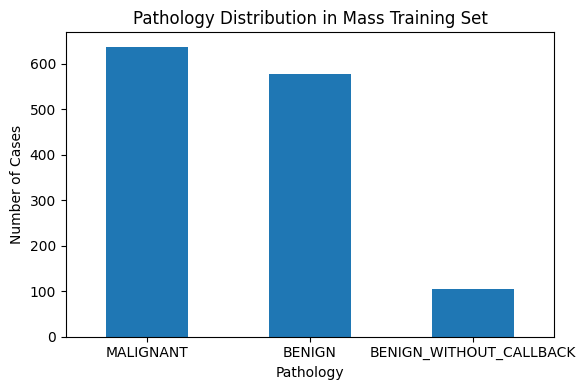


Malignancy Rate by Assessment


,mean,count
assessment,,
2,0.000,77
0,0.147,129
3,0.161,279
4,0.523,533
5,0.980,299



Malignancy Rate by Breast_Density


,mean,count
breast_density,,
4,0.431,109
1,0.474,287
2,0.485,585
3,0.504,337



Malignancy Rate by Mass Margins


,mean,count
mass margins,,
CIRCUMSCRIBED-OBSCURED,0.053,19
CIRCUMSCRIBED,0.105,305
OBSCURED,0.127,197
nan,0.209,43
CIRCUMSCRIBED-ILL_DEFINED,0.481,27
ILL_DEFINED,0.629,278
MICROLOBULATED,0.639,108
OBSCURED-ILL_DEFINED,0.895,19
ILL_DEFINED-SPICULATED,0.920,25



Malignancy Rate by Mass Shape


,mean,count
mass shape,,
LYMPH_NODE,0.000,26
FOCAL_ASYMMETRIC_DENSITY,0.263,19
OVAL,0.283,321
ROUND,0.317,123
LOBULATED,0.341,305
ASYMMETRIC_BREAST_TISSUE,0.400,20
ARCHITECTURAL_DISTORTION,0.650,80
IRREGULAR,0.818,351
IRREGULAR-ARCHITECTURAL_DISTORTION,0.956,45



Malignancy Rate by Subtlety


,mean,count
subtlety,,
3,0.393,257
4,0.416,375
5,0.541,543
2,0.560,100
1,0.732,41


In [36]:
import matplotlib.pyplot as plt

# Create binary label if not already present
mass_train["label"] = (
    mass_train["pathology"].str.upper() == "MALIGNANT"
).astype(int)

# Class distribution
plt.figure(figsize=(6,4))
mass_train["pathology"].value_counts().plot(kind="bar")
plt.title("Pathology Distribution in Mass Training Set")
plt.xlabel("Pathology")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Malignancy rate by metadata
metadata_fields = [
    "assessment",
    "breast_density",
    "mass margins",
    "mass shape",
    "subtlety"
]

for col in metadata_fields:
    if col in mass_train.columns:

        g = (
            mass_train
            .groupby(mass_train[col].astype(str))["label"]
            .agg(["mean", "count"])
        )

        print("\n" + "="*60)
        print(f"Malignancy Rate by {col.title()}")
        print("="*60)

        display(
            g[g["count"] >= 10]
            .sort_values("mean")
            .round(3)
        )

## Helper Functions for Image Retrieval

The following helper functions are defined to simplify image loading throughout the notebook. These functions extract the unique study identifier from the metadata paths and retrieve the corresponding JPEG images stored locally. They are reused in subsequent sections for visualising mammograms, cropped lesion images, and ROI masks.

In [20]:
import os
def uid_from(p): return str(p).split("/")[-2]
def jpegs_in(p):
    folder = os.path.join(JPEG_DIR, uid_from(p))
    return [os.path.join(folder, f) for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))]

## Visualisation of Sample Mammograms

Representative mammograms from the malignant and non-malignant classes are displayed to provide an initial visual understanding of the dataset. This qualitative inspection helps verify that the images have been correctly linked to the metadata and highlights the visual variability present across the two classes.
---



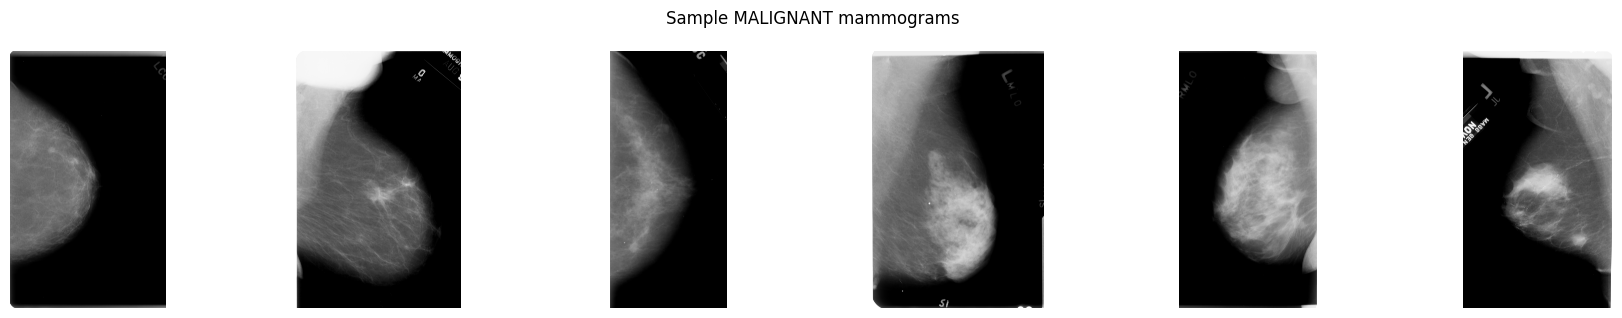

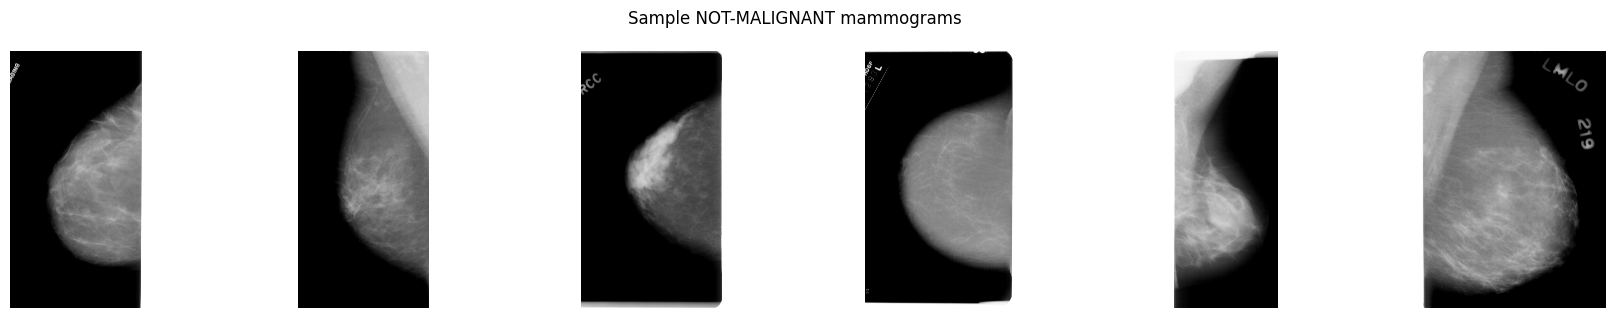

In [21]:
from PIL import Image
import matplotlib.pyplot as plt

def show_grid(df, title, n=6):
    sub = df.sample(min(n, len(df)), random_state=1)
    fig, ax = plt.subplots(1, len(sub), figsize=(3*len(sub), 3.2))
    if len(sub) == 1: ax = [ax]
    for a, (_, r) in zip(ax, sub.iterrows()):
        a.imshow(Image.open(r["full_jpeg"]).convert("L"), cmap="gray"); a.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_grid(img_df[img_df.label == 1], "Sample MALIGNANT mammograms")
show_grid(img_df[img_df.label == 0], "Sample NOT-MALIGNANT mammograms")

## Visualisation of Mammogram and ROI Annotations

The CBIS-DDSM dataset provides expert-annotated Region of Interest (ROI) masks alongside the original mammograms. This section visualises an example mammogram together with its corresponding ROI annotations to verify the image-label mapping and to illustrate how lesion locations are represented within the dataset. These ROI annotations may support future explainability analyses and ROI-guided modelling.

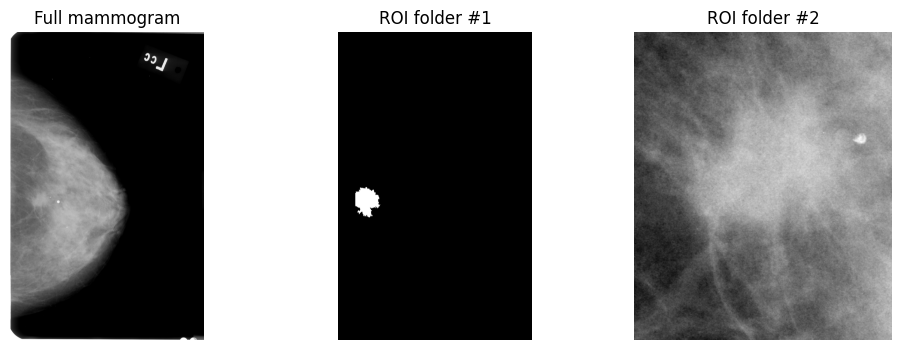

In [22]:
r = mass_train.iloc[0]
full = jpegs_in(r["image file path"])[0]
roi_files = jpegs_in(r["ROI mask file path"])      # usually 2: cropped lesion + binary mask
panels = [("Full mammogram", full)] + [(f"ROI folder #{i+1}", f) for i, f in enumerate(roi_files)]
fig, ax = plt.subplots(1, len(panels), figsize=(4*len(panels), 4))
for a, (t, p) in zip(ax, panels):
    a.imshow(Image.open(p).convert("L"), cmap="gray"); a.set_title(t); a.axis("off")
plt.show()

### Look at which of the ROI-folder images is the binary mask (mostly black with a white blob) versus the cropped lesion — note its position, you'll need it for the attention stage.


## Image Resolution Analysis

Deep learning models require images to be resized to a fixed input resolution before training. This section examines the distribution of mammogram image dimensions to understand the variability in image sizes across the dataset. The results provide useful insights for selecting an appropriate preprocessing strategy for the ResNet-50 baseline model.

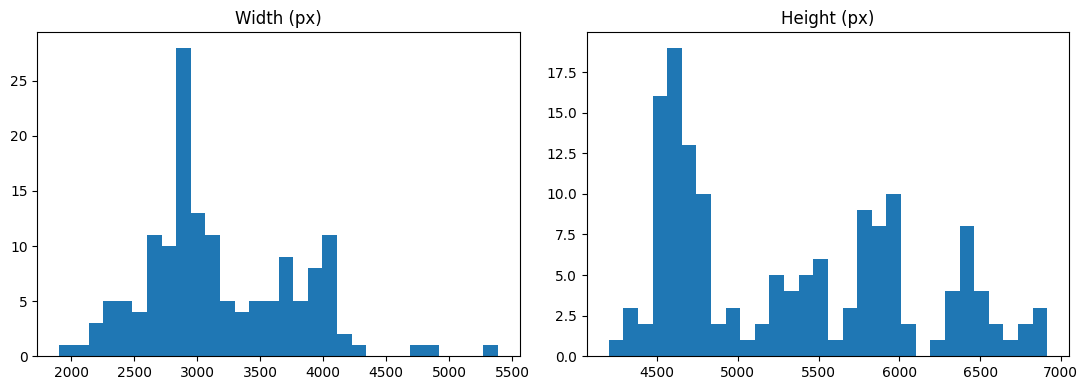

Width  min/median/max: 1906 3020 5386
Height min/median/max: 4201 5273 6916


In [23]:
import numpy as np
samp = img_df["full_jpeg"].sample(min(150, len(img_df)), random_state=2)
sizes = np.array([Image.open(p).size for p in samp])     # (width, height)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(sizes[:,0], bins=30); ax[0].set_title("Width (px)")
ax[1].hist(sizes[:,1], bins=30); ax[1].set_title("Height (px)")
plt.tight_layout(); plt.show()
print("Width  min/median/max:", sizes[:,0].min(), int(np.median(sizes[:,0])), sizes[:,0].max())
print("Height min/median/max:", sizes[:,1].min(), int(np.median(sizes[:,1])), sizes[:,1].max())

## Distribution of Lesion Characteristics

This section examines the frequency of different lesion shapes and lesion margins recorded in the CBIS-DDSM metadata. Understanding the distribution of these radiological descriptors provides insight into the diversity of lesion appearances within the dataset and helps identify common and less frequent categories prior to model development.

In [24]:
for col in ["mass shape", "mass margins"]:
    print(f"\n--- {col} ---")
    print(mass_train[col].value_counts(dropna=False))


--- mass shape ---
mass shape
IRREGULAR                                   351
OVAL                                        321
LOBULATED                                   305
ROUND                                       123
ARCHITECTURAL_DISTORTION                     80
IRREGULAR-ARCHITECTURAL_DISTORTION           45
LYMPH_NODE                                   26
ASYMMETRIC_BREAST_TISSUE                     20
FOCAL_ASYMMETRIC_DENSITY                     19
OVAL-LYMPH_NODE                               6
LOBULATED-IRREGULAR                           5
NaN                                           4
LOBULATED-LYMPH_NODE                          3
ROUND-OVAL                                    3
LOBULATED-ARCHITECTURAL_DISTORTION            2
IRREGULAR-FOCAL_ASYMMETRIC_DENSITY            2
LOBULATED-OVAL                                1
ROUND-IRREGULAR-ARCHITECTURAL_DISTORTION      1
ROUND-LOBULATED                               1
Name: count, dtype: int64

--- mass margins ---
mass marg

## Missing Value Analysis

This section identifies missing values within the clinical metadata to assess data completeness and determine whether preprocessing is required before model development. Understanding the extent and distribution of missing data helps guide appropriate data cleaning and feature engineering strategies.

In [25]:
miss = mass_train.isnull().sum()
print(miss[miss > 0] if miss.sum() else "No missing values")

mass shape       4
mass margins    43
dtype: int64


## Distribution of Mammographic Views and Breast Laterality

This section examines the distribution of mammographic acquisition views (Craniocaudal (CC) and Mediolateral Oblique (MLO)) together with the distribution of left and right breast images. Assessing these characteristics helps evaluate the overall composition of the dataset and identify any potential imbalance that may influence model training.



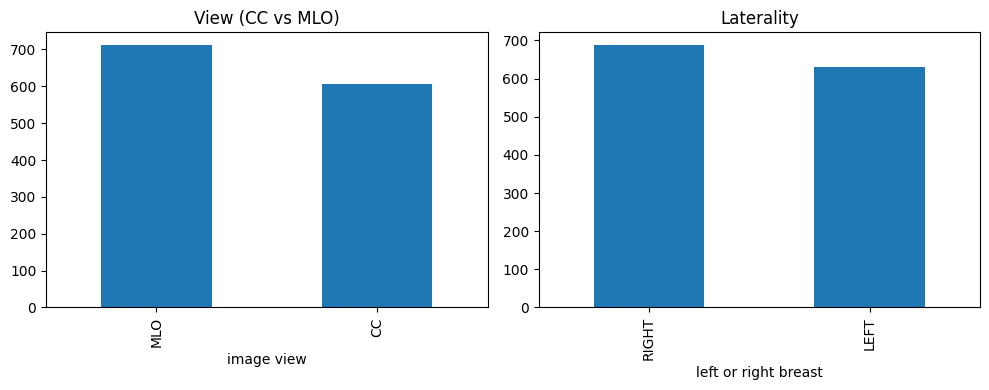

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
mass_train["image view"].value_counts().plot(kind="bar", ax=ax[0], title="View (CC vs MLO)")
mass_train["left or right breast"].value_counts().plot(kind="bar", ax=ax[1], title="Laterality")
plt.tight_layout(); plt.show()